In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Mount Google Drive (Colab will ask for permission)
from google.colab import drive
drive.mount('/content/drive')

# 2. Load the CSV we just exported from GEE
# (Make sure this path matches exactly where it saved in your Drive)
csv_path = '/content/drive/MyDrive/Drought_Assessment_Data/AP_23_Districts_Monthly_Rainfall_1981_2025.csv'
df = pd.read_csv(csv_path)

# 3. Pivot the table so Dates are rows and Districts are columns
# Note: We use 'DISTRICT' here because that's what we exported from GEE
rainfall_df = df.pivot(index='Date', columns='DISTRICT', values='mean')
rainfall_df.index = pd.to_datetime(rainfall_df.index)

print("Data loaded successfully! Here are your 23 districts:")
print(rainfall_df.columns.tolist())

Mounted at /content/drive
Data loaded successfully! Here are your 23 districts:
['Adilabad', 'Anantapur', 'Chittoor', 'East Godavari', 'Guntur', 'Hyderabad', 'Karimnagar', 'Khammam', 'Krishna', 'Kurnool', 'Mahbubnagar', 'Medak', 'Nalgonda', 'Nizamabad', 'Prakasam', 'Rangareddy', 'Sri Potti Sriramulu Nellore', 'Srikakulam', 'Visakhapatnam', 'Vizianagaram', 'Warangal', 'West Godavari', 'Y.s.r.']


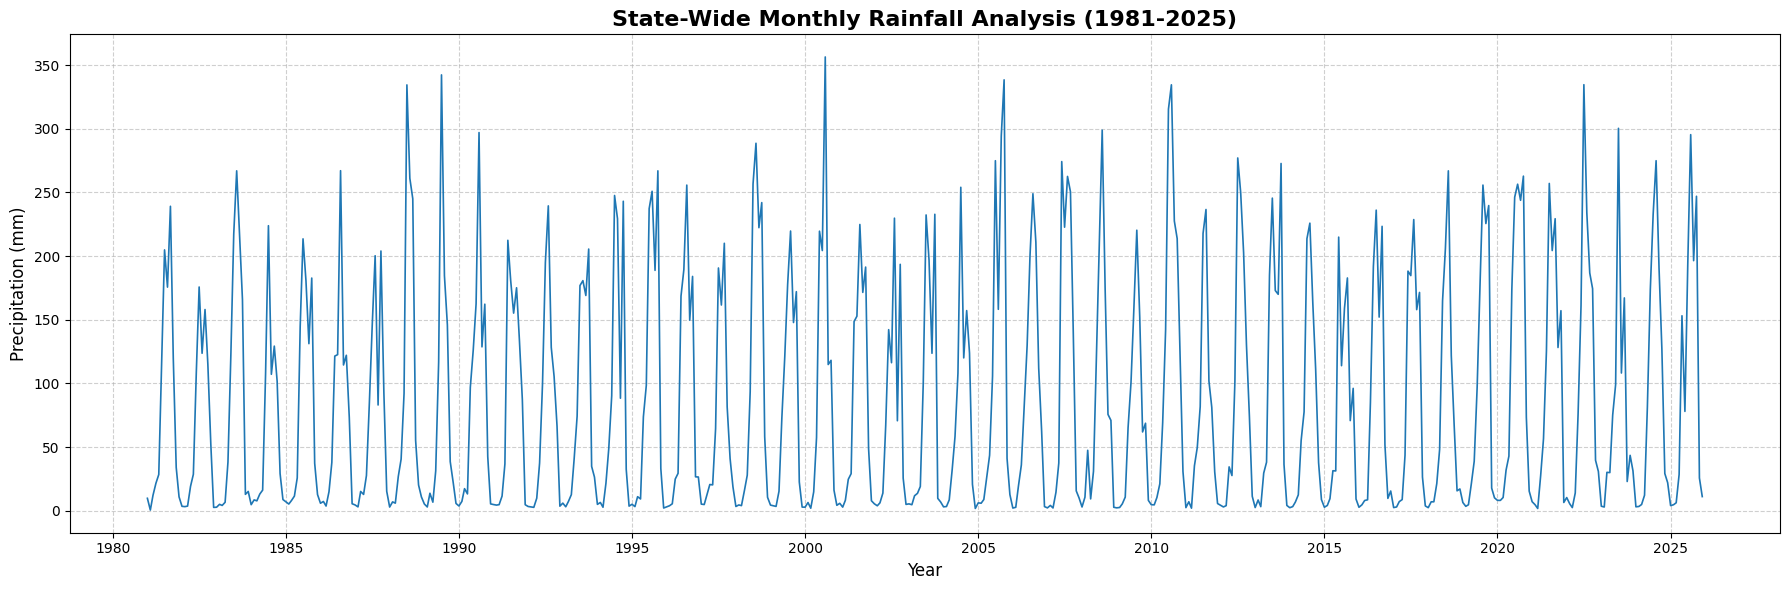

In [ ]:
# Plot the average monthly rainfall across the entire state to show the overall trend
plt.figure(figsize=(18, 6))
plt.plot(rainfall_df.index, rainfall_df.mean(axis=1), color='#1f77b4', linewidth=1.2)

plt.title('State-Wide Monthly Rainfall Analysis (1981-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('/content/drive/MyDrive/Drought_Assessment_Data/Monthly_Rainfall_Analysis.png', dpi=300)
plt.show()

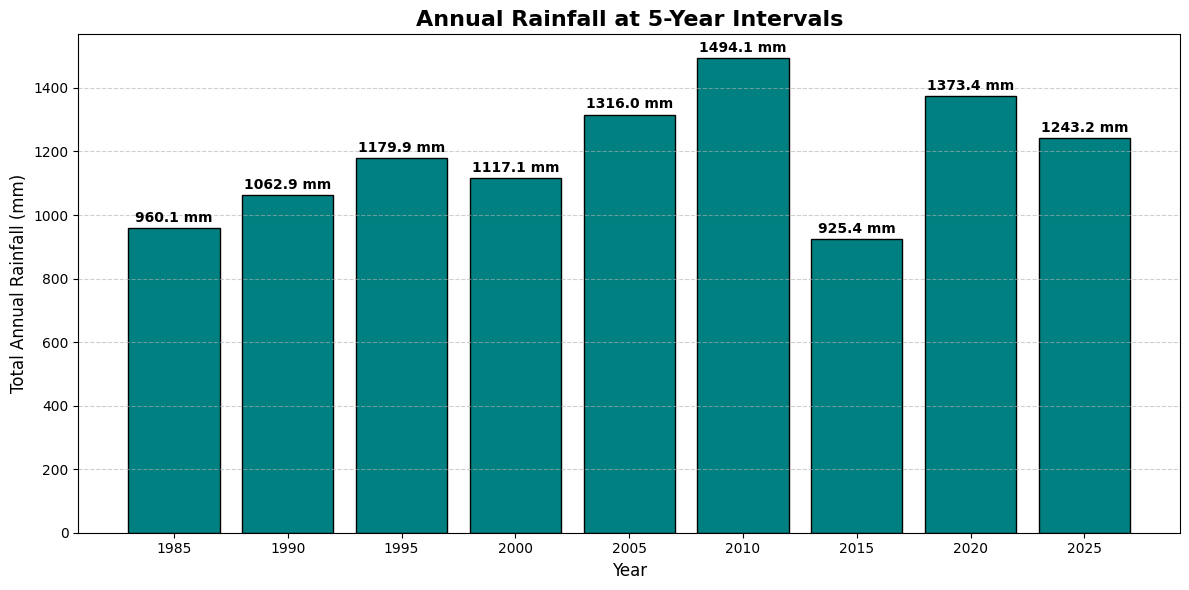

In [ ]:
# 1. Convert monthly data into total annual data
annual_df = rainfall_df.resample('YE').sum() # 'YE' is Year-End frequency
annual_df.index = annual_df.index.year       # Keep just the year numbers

# 2. Filter for exactly every 5 years, up to 2025
years_5 = [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
annual_5yr = annual_df.loc[years_5]

# 3. Plot a Bar Chart (State average for those specific years)
plt.figure(figsize=(12, 6))
bars = plt.bar(annual_5yr.index.astype(str), annual_5yr.mean(axis=1), color='teal', edgecolor='black')

# Add the actual numbers on top of the bars for extra points with the prof!
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{round(yval, 1)} mm', ha='center', va='bottom', fontweight='bold')

plt.title('Annual Rainfall at 5-Year Intervals', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Annual Rainfall (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('/content/drive/MyDrive/Drought_Assessment_Data/Annual_5_Years_Interval.png', dpi=300)
plt.show()

In [ ]:
import scipy.stats as st
import numpy as np

# 1. Define the math function to calculate SPI
def calculate_spi(series):
    # Drop empty data and replace 0s with a tiny number so the math doesn't crash
    s = series.dropna().replace(0, 0.001)

    # Fit the data to a Gamma distribution
    shape, loc, scale = st.gamma.fit(s)
    cdf = st.gamma.cdf(s, shape, loc=loc, scale=scale)

    # Clip the CDF to prevent infinite values, then convert to SPI
    cdf = np.clip(cdf, 0.0001, 0.9999)
    spi_values = st.norm.ppf(cdf)

    # Align back with dates
    result = pd.Series(np.nan, index=series.index)
    result.loc[s.index] = spi_values
    return result

# 2. Calculate the rolling totals for 1, 3, and 12 months
print("Calculating SPI-1 (Monthly)...")
rain_1 = rainfall_df.copy()
spi_1 = rain_1.apply(calculate_spi)

print("Calculating SPI-3 (Seasonal)...")
rain_3 = rainfall_df.rolling(window=3).sum()
spi_3 = rain_3.apply(calculate_spi)

print("Calculating SPI-12 (Annual)...")
rain_12 = rainfall_df.rolling(window=12).sum()
spi_12 = rain_12.apply(calculate_spi)

print("✅ All SPI calculations completed successfully!")

Calculating SPI-1 (Monthly)...
Calculating SPI-3 (Seasonal)...
Calculating SPI-12 (Annual)...
✅ All SPI calculations completed successfully!


In [ ]:
import os

# Create a folder inside your Drive to hold all 23 graphs safely
output_folder = '/content/drive/MyDrive/Drought_Assessment_Data/SPI_Graphs/'
os.makedirs(output_folder, exist_ok=True)

print("Generating 23 District Graphs... Please wait a moment.")

# Loop through every single district one by one
for district in rainfall_df.columns:
    plt.figure(figsize=(14, 6))

    # Plot all three SPIs
    plt.plot(spi_1.index, spi_1[district], label='SPI-1', color='orange', alpha=0.5)
    plt.plot(spi_3.index, spi_3[district], label='SPI-3', color='green', alpha=0.7)
    plt.plot(spi_12.index, spi_12[district], label='SPI-12', color='darkblue', linewidth=2)

    # Add a red dashed line to show the severe drought threshold (SPI = -1.0)
    plt.axhline(0, color='black', linewidth=1)
    plt.axhline(-1.0, color='red', linestyle='--', label='Drought Threshold (≤ -1.0)')

    # Formatting the chart
    plt.title(f'Multi-Scalar SPI Analysis (1981-2025) - {district} District', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Standardized Precipitation Index (SPI)', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()

    # Save the graph directly to Google Drive
    plt.savefig(f"{output_folder}{district}_SPI_Analysis.png", dpi=300)
    plt.close() # Close to save Colab memory

print(f"✅ Success! All 23 graphs have been saved to your Google Drive in the 'SPI_Graphs' folder.")

Generating 23 District Graphs... Please wait a moment.
✅ Success! All 23 graphs have been saved to your Google Drive in the 'SPI_Graphs' folder.


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the shapefile directly from your Drive (this defines 'ap_map'!)
zip_path = "zip:///content/drive/MyDrive/Drought_Assessment_Data/India_Districts_2011.zip"
# Note: Ensure this zip_path exactly matches the name of the zip file in your Drive!

india_map = gpd.read_file(zip_path)

# Filter for the 23 districts of Andhra Pradesh
ap_map = india_map[india_map['ST_NM'] == 'Andhra Pradesh'].copy()
ap_map = ap_map.rename(columns={'DISTRICT': 'DISTRICT'}) # Ensure column name matches

# 2. Choose a specific drought month to map (e.g., July 2002)
target_date = '2002-07-01'

# 3. Extract the SPI values for that specific date for all 23 districts
spi_map_data = pd.DataFrame({
    'DISTRICT': spi_1.columns,
    'SPI_1': spi_1.loc[target_date].values,
    'SPI_3': spi_3.loc[target_date].values,
    'SPI_12': spi_12.loc[target_date].values
})

# 4. Merge our SPI calculations with the shapefile
merged_spi_map = ap_map.merge(spi_map_data, on='DISTRICT')

# 5. Draw the 3 Maps side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# A standard drought color map: Red is dry (negative SPI), Blue is wet (positive SPI)
cmap = 'RdYlBu'
vmin, vmax = -2.5, 2.5 # Fix the scale so all three maps are perfectly comparable

# Map for SPI-1
merged_spi_map.plot(column='SPI_1', cmap=cmap, legend=True, ax=axes[0], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[0].set_title(f'SPI-1 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Map for SPI-3
merged_spi_map.plot(column='SPI_3', cmap=cmap, legend=True, ax=axes[1], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[1].set_title(f'SPI-3 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Map for SPI-12
merged_spi_map.plot(column='SPI_12', cmap=cmap, legend=True, ax=axes[2], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[2].set_title(f'SPI-12 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/Drought_Assessment_Data/SPI_Spatial_Maps_{target_date[:7]}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Spatial Maps for {target_date} generated and saved to Drive!")

DataSourceError: '/vsizip//content/drive/MyDrive/Drought_Assessment_Data/India_Districts_2011.zip' does not exist in the file system, and is not recognized as a supported dataset name.

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the shapefile directly from your Drive (this defines 'ap_map'!)
zip_path = "zip:///content/drive/MyDrive/Drought_Assessment_Data/India_Districts_2011.zip"
# Note: Ensure this zip_path exactly matches the name of the zip file in your Drive!

india_map = gpd.read_file(zip_path)

# Filter for the 23 districts of Andhra Pradesh
ap_map = india_map[india_map['ST_NM'] == 'Andhra Pradesh'].copy()
ap_map = ap_map.rename(columns={'DISTRICT': 'DISTRICT'}) # Ensure column name matches

# 2. Choose a specific drought month to map (e.g., July 2002)
target_date = '2002-07-01'

# 3. Extract the SPI values for that specific date for all 23 districts
spi_map_data = pd.DataFrame({
    'DISTRICT': spi_1.columns,
    'SPI_1': spi_1.loc[target_date].values,
    'SPI_3': spi_3.loc[target_date].values,
    'SPI_12': spi_12.loc[target_date].values
})

# 4. Merge our SPI calculations with the shapefile
merged_spi_map = ap_map.merge(spi_map_data, on='DISTRICT')

# 5. Draw the 3 Maps side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# A standard drought color map: Red is dry (negative SPI), Blue is wet (positive SPI)
cmap = 'RdYlBu'
vmin, vmax = -2.5, 2.5 # Fix the scale so all three maps are perfectly comparable

# Map for SPI-1
merged_spi_map.plot(column='SPI_1', cmap=cmap, legend=True, ax=axes[0], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[0].set_title(f'SPI-1 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Map for SPI-3
merged_spi_map.plot(column='SPI_3', cmap=cmap, legend=True, ax=axes[1], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[1].set_title(f'SPI-3 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Map for SPI-12
merged_spi_map.plot(column='SPI_12', cmap=cmap, legend=True, ax=axes[2], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[2].set_title(f'SPI-12 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/Drought_Assessment_Data/SPI_Spatial_Maps_{target_date[:7]}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Spatial Maps for {target_date} generated and saved to Drive!")

DataSourceError: '/vsizip//content/drive/MyDrive/Drought_Assessment_Data/India_Districts_2011.zip' does not exist in the file system, and is not recognized as a supported dataset name.

In [ ]:
# 1. Install the Mann-Kendall library
!pip install pymannkendall

import pymannkendall as mk
import pandas as pd

print("Calculating Mann-Kendall and Sen's Slope...")

# 2. Define a function to run the test on all districts
def calculate_trend(spi_df, spi_name):
    results = []
    for district in spi_df.columns:
        # Get the data and drop empty values
        data = spi_df[district].dropna()

        # Run the MK test
        trend_result = mk.original_test(data)

        results.append({
            'DISTRICT': district,
            'SPI_Type': spi_name,
            'Trend': trend_result.trend,       # 'increasing', 'decreasing', or 'no trend'
            'MK_Z_Score': trend_result.z,      # The statistical MK value (good for mapping)
            'Sens_Slope': trend_result.slope,  # The magnitude of the trend
            'p_value': trend_result.p          # Significance level
        })
    return pd.DataFrame(results)

# 3. Run the function for SPI-1, SPI-3, and SPI-12
mk_spi1 = calculate_trend(spi_1, 'SPI-1')
mk_spi3 = calculate_trend(spi_3, 'SPI-3')
mk_spi12 = calculate_trend(spi_12, 'SPI-12')

# Combine them all into one master table and save it
master_trends = pd.concat([mk_spi1, mk_spi3, mk_spi12])
master_trends.to_csv('/content/drive/MyDrive/Drought_Assessment_Data/MK_Sens_Slope_Results.csv', index=False)

print("✅ Math complete! Results saved to MK_Sens_Slope_Results.csv in your Drive.")

Calculating Mann-Kendall and Sen's Slope...
✅ Math complete! Results saved to MK_Sens_Slope_Results.csv in your Drive.


In [ ]:
!pip install geopandas
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# 1. Load the shapefile directly from your Google Drive zip file
zip_path = "zip:///content/drive/MyDrive/Drought_Assessment_Data/2011_Dist.zip"
# Note: change "India_Districts_2011.zip" to exactly what your zip file is called!

india_map = gpd.read_file(zip_path)

# Filter out just Andhra Pradesh (which gives us the 23 districts)
ap_map = india_map[india_map['ST_NM'] == 'Andhra Pradesh'].copy()

# Ensure the district column name matches our data (DataMeet uses 'DISTRICT')
ap_map = ap_map.rename(columns={'DISTRICT': 'DISTRICT'})

# 2. Set up a folder for the maps
map_folder = '/content/drive/MyDrive/Drought_Assessment_Data/Trend_Maps/'
os.makedirs(map_folder, exist_ok=True)

# 3. Define a function to draw and save the maps
def plot_trend_maps(mk_data, spi_name):
    # Link the map to the math results
    merged = ap_map.merge(mk_data, on='DISTRICT')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Map 1: Sen's Slope (Magnitude of change)
    # Red means getting drier (negative slope), Blue means getting wetter
    merged.plot(column='Sens_Slope', cmap='RdBu', legend=True, ax=axes[0],
                legend_kwds={'label': "Sen's Slope Value"})
    axes[0].set_title(f"Sen's Slope Map for {spi_name}", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Map 2: Mann-Kendall Z-Score (Statistical Trend)
    # Z > 1.96 or < -1.96 means highly significant
    merged.plot(column='MK_Z_Score', cmap='RdYlGn', legend=True, ax=axes[1],
                legend_kwds={'label': "MK Z-Score"})
    axes[1].set_title(f"Mann-Kendall Trend Map for {spi_name}", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(f"{map_folder}{spi_name}_Trend_Maps.png", dpi=300, bbox_inches='tight')
    plt.close()

# 4. Generate the maps!
print("Drawing maps...")
plot_trend_maps(mk_spi1, 'SPI-1')
plot_trend_maps(mk_spi3, 'SPI-3')
plot_trend_maps(mk_spi12, 'SPI-12')

print(f"✅ Success! All 6 maps are saved in your Drive inside the 'Trend_Maps' folder.")

Drawing maps...
✅ Success! All 6 maps are saved in your Drive inside the 'Trend_Maps' folder.


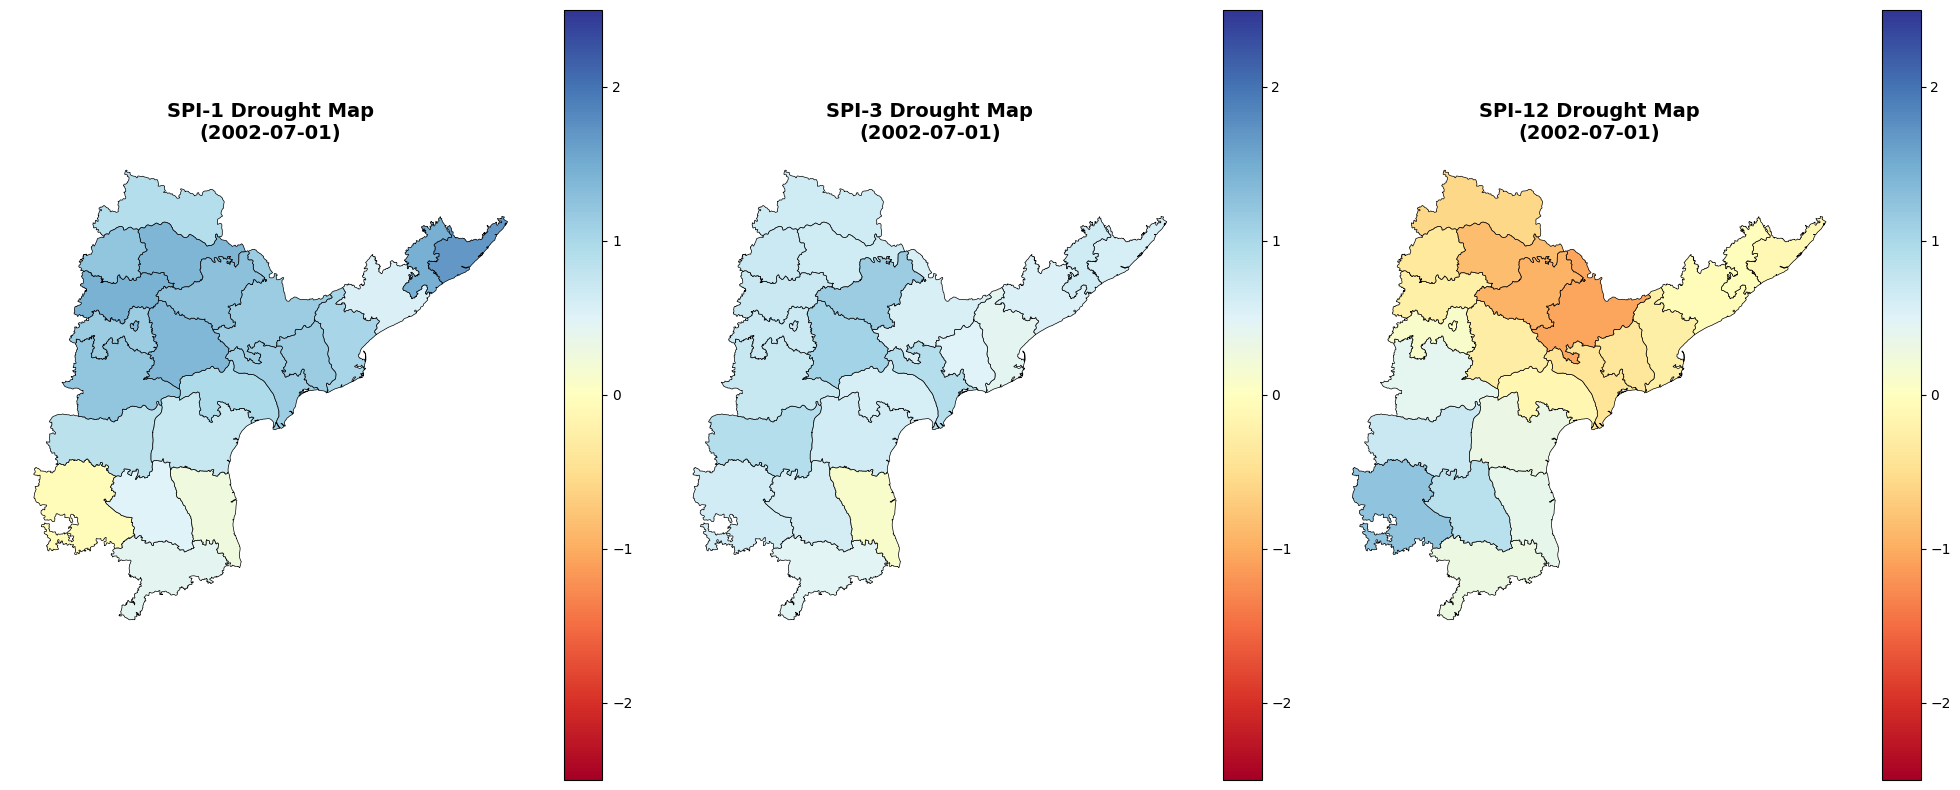

✅ Spatial Maps for 2002-07-01 generated and saved to Drive!


In [ ]:
# Choose a specific month to map (e.g., a known severe drought month like July 2002)
# You can easily change this date to whatever month you want to show in the report!
target_date = '2002-07-01'

# 1. Extract the SPI values for that specific date for all 23 districts
spi_map_data = pd.DataFrame({
    'DISTRICT': spi_1.columns,
    'SPI_1': spi_1.loc[target_date].values,
    'SPI_3': spi_3.loc[target_date].values,
    'SPI_12': spi_12.loc[target_date].values
})

# 2. Merge our SPI calculations with the 'ap_map' shapefile we loaded in the previous step
merged_spi_map = ap_map.merge(spi_map_data, on='DISTRICT')

# 3. Draw the 3 Maps side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# A standard drought color map: Red is dry (negative SPI), Blue is wet (positive SPI)
cmap = 'RdYlBu'
vmin, vmax = -2.5, 2.5 # Fix the scale so all three maps are perfectly comparable

# Map for SPI-1
merged_spi_map.plot(column='SPI_1', cmap=cmap, legend=True, ax=axes[0], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[0].set_title(f'SPI-1 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Map for SPI-3
merged_spi_map.plot(column='SPI_3', cmap=cmap, legend=True, ax=axes[1], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[1].set_title(f'SPI-3 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Map for SPI-12
merged_spi_map.plot(column='SPI_12', cmap=cmap, legend=True, ax=axes[2], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[2].set_title(f'SPI-12 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/Drought_Assessment_Data/SPI_Spatial_Maps_{target_date[:7]}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Spatial Maps for {target_date} generated and saved to Drive!")

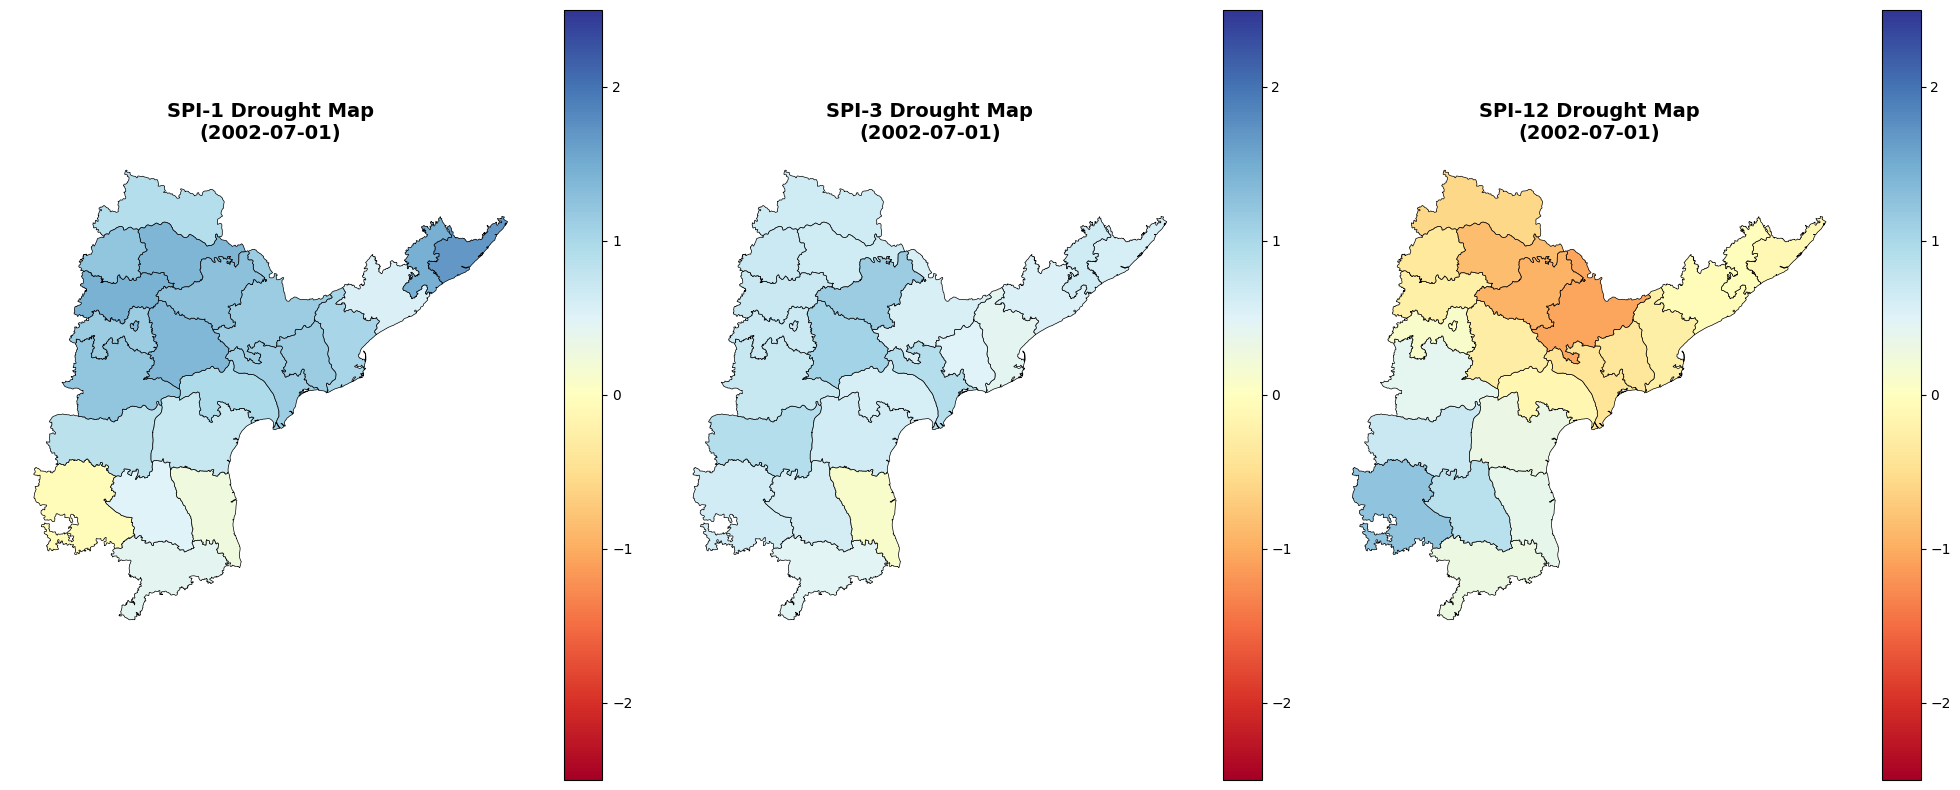

✅ Spatial Maps for 2002-07-01 generated and saved to Drive!


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the shapefile directly from your Drive (this defines 'ap_map'!)
zip_path = "zip:///content/drive/MyDrive/Drought_Assessment_Data/2011_Dist.zip"
# Note: Ensure this zip_path exactly matches the name of the zip file in your Drive!

india_map = gpd.read_file(zip_path)

# Filter for the 23 districts of Andhra Pradesh
ap_map = india_map[india_map['ST_NM'] == 'Andhra Pradesh'].copy()
ap_map = ap_map.rename(columns={'DISTRICT': 'DISTRICT'}) # Ensure column name matches

# 2. Choose a specific drought month to map (e.g., July 2002)
target_date = '2002-07-01'

# 3. Extract the SPI values for that specific date for all 23 districts
spi_map_data = pd.DataFrame({
    'DISTRICT': spi_1.columns,
    'SPI_1': spi_1.loc[target_date].values,
    'SPI_3': spi_3.loc[target_date].values,
    'SPI_12': spi_12.loc[target_date].values
})

# 4. Merge our SPI calculations with the shapefile
merged_spi_map = ap_map.merge(spi_map_data, on='DISTRICT')

# 5. Draw the 3 Maps side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# A standard drought color map: Red is dry (negative SPI), Blue is wet (positive SPI)
cmap = 'RdYlBu'
vmin, vmax = -2.5, 2.5 # Fix the scale so all three maps are perfectly comparable

# Map for SPI-1
merged_spi_map.plot(column='SPI_1', cmap=cmap, legend=True, ax=axes[0], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[0].set_title(f'SPI-1 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Map for SPI-3
merged_spi_map.plot(column='SPI_3', cmap=cmap, legend=True, ax=axes[1], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[1].set_title(f'SPI-3 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Map for SPI-12
merged_spi_map.plot(column='SPI_12', cmap=cmap, legend=True, ax=axes[2], vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.5)
axes[2].set_title(f'SPI-12 Drought Map\n({target_date})', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/Drought_Assessment_Data/SPI_Spatial_Maps_{target_date[:7]}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Spatial Maps for {target_date} generated and saved to Drive!")